In [13]:
import torch
torch.cuda.is_available()

True

In [14]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

In [15]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    download=True,
    transform=transform
)

animal_classes = [2,3,4,5,6,7]

dataset.targets = np.array(dataset.targets)
mask = np.isin(dataset.targets, animal_classes)

dataset.data = dataset.data[mask]
dataset.targets = dataset.targets[mask]

loader = DataLoader(dataset, batch_size=128, shuffle=True)

(np.float64(-0.5), np.float64(265.5), np.float64(265.5), np.float64(-0.5))

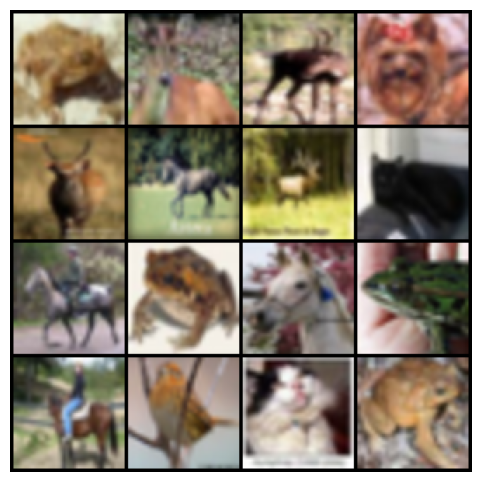

In [16]:
real_batch = next(iter(loader))

plt.figure(figsize=(6,6))
grid = torchvision.utils.make_grid(real_batch[0][:16], nrow=4, normalize=True)
plt.imshow(grid.permute(1,2,0))
plt.axis("off")

In [17]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100, 256*8*8),
            nn.BatchNorm1d(256*8*8),
            nn.ReLU(),

            nn.Unflatten(1,(256,8,8)),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

In [18]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(256*8*8,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

In [20]:
criterion = nn.BCELoss()

g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))

Epoch 0 | D Loss 0.004 | G Loss 8.505


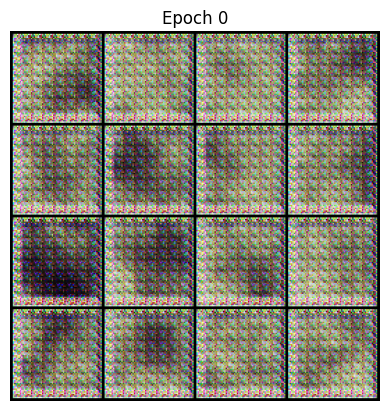

Epoch 1 | D Loss 0.063 | G Loss 5.967
Epoch 2 | D Loss 0.314 | G Loss 2.679
Epoch 3 | D Loss 0.505 | G Loss 4.242
Epoch 4 | D Loss 0.058 | G Loss 3.909
Epoch 5 | D Loss 1.348 | G Loss 8.357


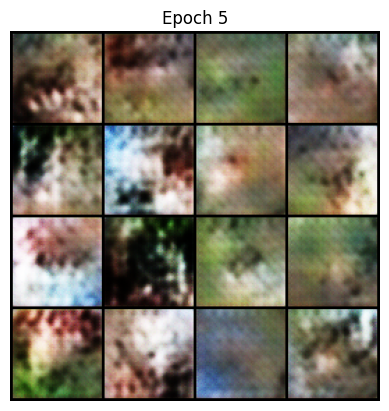

Epoch 6 | D Loss 0.099 | G Loss 3.249
Epoch 7 | D Loss 0.126 | G Loss 3.564
Epoch 8 | D Loss 0.139 | G Loss 3.585
Epoch 9 | D Loss 0.102 | G Loss 3.556
Epoch 10 | D Loss 0.036 | G Loss 4.564


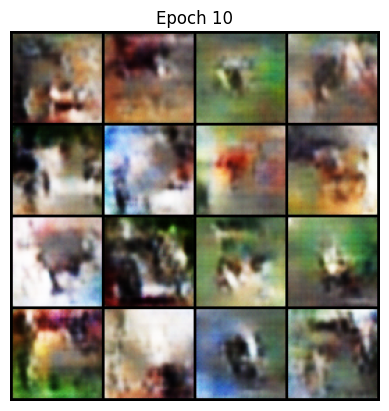

Epoch 11 | D Loss 0.338 | G Loss 2.298
Epoch 12 | D Loss 0.058 | G Loss 3.637
Epoch 13 | D Loss 0.090 | G Loss 4.082
Epoch 14 | D Loss 0.368 | G Loss 3.890
Epoch 15 | D Loss 0.163 | G Loss 5.215


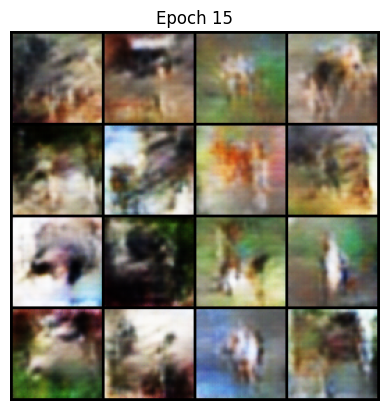

Epoch 16 | D Loss 0.157 | G Loss 2.899
Epoch 17 | D Loss 0.035 | G Loss 4.651
Epoch 18 | D Loss 1.308 | G Loss 2.900
Epoch 19 | D Loss 0.112 | G Loss 2.678
Epoch 20 | D Loss 2.269 | G Loss 1.364


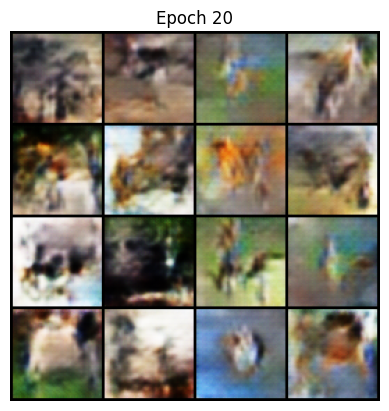

Epoch 21 | D Loss 0.560 | G Loss 2.665
Epoch 22 | D Loss 0.013 | G Loss 5.743
Epoch 23 | D Loss 0.103 | G Loss 4.552
Epoch 24 | D Loss 0.102 | G Loss 5.074
Epoch 25 | D Loss 0.011 | G Loss 5.139


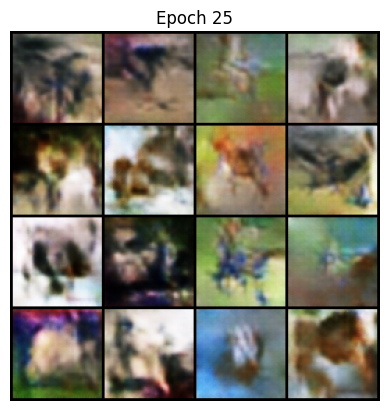

Epoch 26 | D Loss 1.844 | G Loss 1.148
Epoch 27 | D Loss 0.169 | G Loss 6.286
Epoch 28 | D Loss 0.039 | G Loss 4.816
Epoch 29 | D Loss 0.127 | G Loss 3.770


In [21]:
fixed_noise = torch.randn(16,100).to(device)

g_losses = []
d_losses = []

epochs = 30

for epoch in range(epochs):

    for real,_ in loader:

        real = real.to(device)
        batch_size = real.size(0)

        real_label = torch.ones(batch_size,1).to(device)
        fake_label = torch.zeros(batch_size,1).to(device)


        noise = torch.randn(batch_size,100).to(device)
        fake_images = G(noise)

        D_real = D(real)
        D_fake = D(fake_images.detach())

        d_loss = criterion(D_real,real_label) + criterion(D_fake,fake_label)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()


        output = D(fake_images)
        g_loss = criterion(output,real_label)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(f"Epoch {epoch} | D Loss {d_loss:.3f} | G Loss {g_loss:.3f}")

    if epoch % 5 == 0:
        with torch.no_grad():
            fake = G(fixed_noise).cpu()
        grid = torchvision.utils.make_grid(fake, nrow=4, normalize=True)
        plt.imshow(grid.permute(1,2,0))
        plt.title(f"Epoch {epoch}")
        plt.axis("off")
        plt.show()

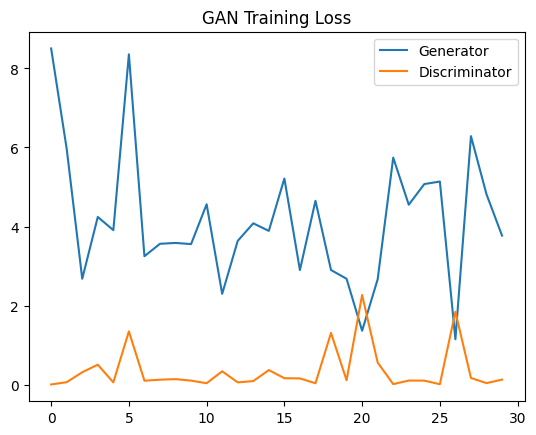

In [22]:
plt.plot(g_losses,label="Generator")
plt.plot(d_losses,label="Discriminator")
plt.legend()
plt.title("GAN Training Loss")
plt.show()